<a href="https://colab.research.google.com/github/splakplutoy/tugas-sisdas-cv/blob/main/tugas_sisdas_cv_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Kelompok 3
1. Ferdiansyah Dwana Putra Santoso
2. Tazakka Ghefira Erza

# Tujuan Notebook Training

Notebook ini membuat model CNN custom untuk mengklasifikasikan gambar hasil casting menjadi dua kelas: `def_front` atau barang cacat, dan `ok_front` atau barang bagus. Proses training dilakukan dengan kode agar setiap tahap dapat dikontrol langsung, mulai dari pengambilan dataset, preprocessing, augmentasi, pemilihan arsitektur CNN, sampai penyimpanan model.

Model yang dibuat di notebook ini kemudian dibandingkan dengan model dari Teachable Machine pada notebook evaluasi. Karena model custom dibuat manual, kita dapat melihat dan mengubah detail seperti ukuran input, jenis layer, augmentasi, callback, dan threshold prediksi.


## Persiapan Dataset

Cell ini mengunduh dataset casting dari Kaggle, menetapkan seed agar hasil eksperimen lebih konsisten, lalu menentukan folder `train` dan `test`. Folder `train` digunakan untuk melatih dan memvalidasi model, sedangkan folder `test` disimpan untuk evaluasi akhir supaya pengukuran performa tidak bias.

Gambar diproses sebagai citra grayscale karena bentuk cacat pada produk casting lebih penting daripada warna. Pendekatan ini juga membuat model lebih ringan dibandingkan memakai input RGB.


In [2]:
!pip install kagglehub -q

import os
import random
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

SEED = 42
IMG_SIZE = (300, 300)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

kagglehub.login()

print("\nMengunduh dataset...")
dataset_path = Path(kagglehub.dataset_download("ravirajsinh45/real-life-industrial-dataset-of-casting-product"))
print(f"Data berhasil diunduh dan siap digunakan di folder: {dataset_path}")

base_dir = dataset_path / 'casting_data' / 'casting_data'
if not base_dir.exists():
    base_dir = dataset_path / 'casting_data'

train_dir = base_dir / 'train'
test_dir = base_dir / 'test'

print("\nFolder dataset:")
print("Train:", train_dir)
print("Test :", test_dir)





Mengunduh dataset...
Using Colab cache for faster access to the 'real-life-industrial-dataset-of-casting-product' dataset.
Data berhasil diunduh dan siap digunakan di folder: /kaggle/input/real-life-industrial-dataset-of-casting-product

Folder dataset:
Train: /kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train
Test : /kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test
Kaggle credentials set.
Kaggle credentials successfully validated.


## Eksplorasi Data

Bagian ini menampilkan jumlah gambar pada setiap kelas dan contoh gambar dari kelas OK serta Defective. Eksplorasi sederhana ini penting untuk memastikan struktur dataset benar, kelas terbaca sesuai harapan, dan perbedaan visual antar kelas dapat diamati sebelum model dilatih.

Jika jumlah data antar kelas tidak seimbang, model dapat cenderung lebih sering menebak kelas mayoritas. Karena itu distribusi kelas perlu dilihat sebelum masuk ke training.


Distribusi dataset:
Train Defective: 3758
Train OK       : 2875
Test Defective : 453
Test OK        : 262


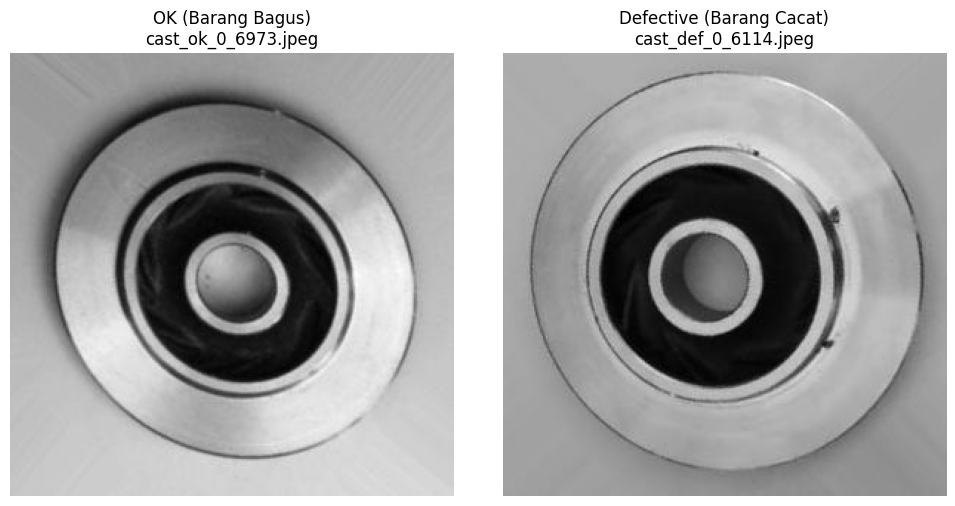

In [3]:
# Eksplorasi singkat dataset dan distribusi kelas
class_dirs = {
    'Train Defective': train_dir / 'def_front',
    'Train OK': train_dir / 'ok_front',
    'Test Defective': test_dir / 'def_front',
    'Test OK': test_dir / 'ok_front',
}

print("Distribusi dataset:")
for name, folder in class_dirs.items():
    count = len([p for p in folder.iterdir() if p.is_file()])
    print(f"{name:15}: {count}")

rng = random.Random(SEED)
ok_img_path = rng.choice(list((train_dir / 'ok_front').glob('*')))
def_img_path = rng.choice(list((train_dir / 'def_front').glob('*')))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(mpimg.imread(ok_img_path), cmap='gray')
ax[0].set_title(f'OK (Barang Bagus)\n{ok_img_path.name}')
ax[0].axis('off')

ax[1].imshow(mpimg.imread(def_img_path), cmap='gray')
ax[1].set_title(f'Defective (Barang Cacat)\n{def_img_path.name}')
ax[1].axis('off')

plt.tight_layout()
plt.show()




## Preprocessing dan Augmentasi

Nilai pixel gambar dinormalisasi dari rentang 0-255 menjadi 0-1 dengan `rescale=1./255`. Normalisasi membantu proses optimasi karena input model berada pada skala yang lebih stabil.

Data training juga diberi augmentasi seperti rotasi kecil, zoom, pergeseran posisi, perubahan brightness, dan horizontal flip. Tujuannya adalah membuat model lebih tahan terhadap variasi posisi, pencahayaan, dan orientasi gambar. Validation split sebesar 20 persen digunakan untuk memantau performa model pada data yang tidak dipakai langsung untuk update bobot.


In [4]:
# Data training dan validation dipisah dari folder train.
# Folder test hanya dipakai nanti untuk evaluasi final.
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VALIDATION_SPLIT,
    rotation_range=10,
    zoom_range=0.15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VALIDATION_SPLIT
)

print("Memuat Data Training:")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=SEED
)

print("\nMemuat Data Validation:")
val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=SEED,
    shuffle=False
)

print("\nIndeks Kelas:", train_generator.class_indices)




Memuat Data Training:
Found 5307 images belonging to 2 classes.

Memuat Data Validation:
Found 1326 images belonging to 2 classes.

Indeks Kelas: {'def_front': 0, 'ok_front': 1}


## Arsitektur dan Proses Training

Model custom menggunakan beberapa blok `Conv2D`, `BatchNormalization`, dan `MaxPooling2D` untuk mengekstraksi pola visual dari gambar casting. Layer konvolusi awal menangkap pola sederhana seperti tepi dan tekstur, sedangkan layer yang lebih dalam menangkap pola cacat yang lebih kompleks.

`GlobalAveragePooling2D`, `Dense`, dan `Dropout` digunakan pada bagian akhir untuk menghasilkan prediksi biner. Fungsi aktivasi terakhir adalah `sigmoid`, sehingga output model berupa probabilitas kelas positif. Callback `ModelCheckpoint`, `EarlyStopping`, dan `ReduceLROnPlateau` membantu menyimpan bobot terbaik, menghentikan training saat validasi tidak membaik, dan menurunkan learning rate ketika proses belajar mulai stagnan.


In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization, Conv2D, Dense, Dropout, GlobalAveragePooling2D, Input, MaxPooling2D
from tensorflow.keras.models import Sequential

model = Sequential([
    Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 1)),

    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Ringkasan Arsitektur Model:")
model.summary()

callbacks = [
    ModelCheckpoint(
        'best_model_kustom_qc.weights.h5',
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("\nMemulai proses training. Silakan tunggu...")
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks
)

model.save('model_kustom_qc.keras')
print("\nTraining selesai!")
print("Bobot model terbaik tersimpan sebagai: best_model_kustom_qc.weights.h5")
print("Model akhir tersimpan sebagai   : model_kustom_qc.keras")




Ringkasan Arsitektur Model:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 298, 298, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 298, 298, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 149, 149, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 147, 147, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 147, 147, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 71, 71, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 35, 35, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 33, 33, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 33, 33, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,785 (1.61 MB)

 Trainable params: 421,825 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)


Memulai proses training. Silakan tunggu...
Epoch 1/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.6770 - loss: 0.6076
Epoch 1: val_loss improved from None to 4.95089, saving model to best_model_kustom_qc.weights.h5

Epoch 1: finished saving model to best_model_kustom_qc.weights.h5
166/166 ━━━━━━━━━━━━━━━━━━━━ 109s 554ms/step - accuracy: 0.7249 - loss: 0.5451 - val_accuracy: 0.4336 - val_loss: 4.9509 - learning_rate: 0.0010
Epoch 2/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.8726 - loss: 0.3226
Epoch 2: val_loss improved from 4.95089 to 3.05301, saving model to best_model_kustom_qc.weights.h5

Epoch 2: finished saving model to best_model_kustom_qc.weights.h5
166/166 ━━━━━━━━━━━━━━━━━━━━ 59s 358ms/step - accuracy: 0.8851 - loss: 0.2897 - val_accuracy: 0.4336 - val_loss: 3.0530 - learning_rate: 0.0010
Epoch 3/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.9240 - loss: 0.1845
Epoch 3: val_loss did not improve from 3.05301
166/166 ━━━━━━━━━━━━━━━━━

## Membaca Kurva Training

Kurva akurasi dan loss digunakan untuk menganalisis apakah model belajar dengan baik. Jika akurasi training naik tetapi akurasi validation jauh lebih rendah, model kemungkinan mengalami overfitting. Jika akurasi training dan validation sama-sama rendah, model kemungkinan underfitting atau belum cukup belajar.

Hasil dari notebook ini menjadi dasar perbandingan dengan Teachable Machine. Perbedaannya, di sini arsitektur, augmentasi, callback, dan penyimpanan model ditentukan langsung lewat kode, sedangkan Teachable Machine menyederhanakan proses training melalui antarmuka visual.


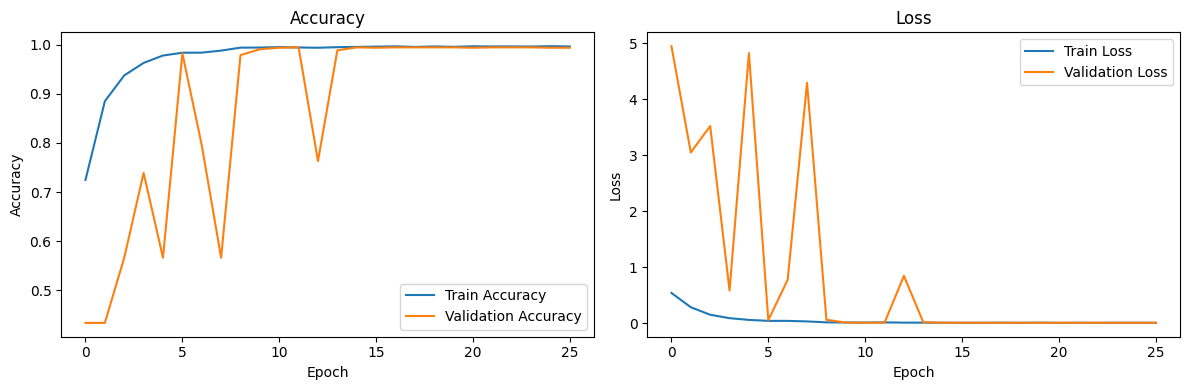

In [6]:
# Visualisasi kurva training untuk membaca overfitting/underfitting
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
ax[0].set_title('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Validation Loss')
ax[1].set_title('Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()


